# Medical Misinformation Shield — MASTER NOTEBOOK
**Runs all 5 experiments in one notebook. Saves everything to Google Drive.**

⚠️ **Before running:** Runtime → Change runtime type → A100 GPU

**Steps:**
1. Run Cell 1 — Mount Google Drive
2. Run Cell 2 — Install everything
3. Runtime → Run all
4. Come back in ~2 hours
5. Find results in Google Drive → medical_misinfo_shield → outputs/

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 1 — MOUNT GOOGLE DRIVE (run this first manually)
# ════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os

# All outputs go to your Google Drive — survives session restarts
DRIVE_BASE = '/content/drive/MyDrive/medical_misinfo_shield'
os.makedirs(f'{DRIVE_BASE}/outputs/models/biobert_finetuned', exist_ok=True)
os.makedirs(f'{DRIVE_BASE}/outputs/models/biobert_lora', exist_ok=True)
os.makedirs(f'{DRIVE_BASE}/outputs/figures', exist_ok=True)
os.makedirs(f'{DRIVE_BASE}/data', exist_ok=True)

# Create symlinks so all notebooks write to Drive automatically
if not os.path.exists('/content/outputs'):
    os.symlink(f'{DRIVE_BASE}/outputs', '/content/outputs')
if not os.path.exists('/content/data'):
    os.symlink(f'{DRIVE_BASE}/data', '/content/data')

os.chdir('/content')
print(f'✓ Google Drive mounted')
print(f'✓ Outputs will be saved to: {DRIVE_BASE}/outputs/')
print(f'✓ Data will be saved to: {DRIVE_BASE}/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ Outputs will be saved to: /content/drive/MyDrive/medical_misinfo_shield/outputs/
✓ Data will be saved to: /content/drive/MyDrive/medical_misinfo_shield/data/


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 2 — INSTALL ALL DEPENDENCIES
# ════════════════════════════════════════════════════════
!pip install -q transformers==4.38.0
!pip install -q peft==0.9.0
!pip install -q torch accelerate
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q wordcloud deep-translator datasets joblib
!pip install -q torchao==0.16.0
print('✓ All dependencies installed')

✓ All dependencies installed


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 3 — ALL IMPORTS
# ════════════════════════════════════════════════════════
import os, json, time, warnings, itertools, hashlib, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
from torch.optim import AdamW
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

MODEL_NAME = 'dmis-lab/biobert-v1.1'

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('✓ All imports done')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
✓ All imports done


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 4 — BUILD DATASET
# ════════════════════════════════════════════════════════
if os.path.exists('data/train.csv'):
    print('✓ Data already exists in Drive — loading')
    train_df = pd.read_csv('data/train.csv')
    val_df   = pd.read_csv('data/val.csv')
    test_df  = pd.read_csv('data/test.csv')
else:
    print('Building dataset...')
    misinfo = [
        "Ivermectin cures COVID-19 with 98 percent efficacy according to suppressed studies doctors hide",
        "Miracle cure drinking bleach kills coronavirus instantly recommended by alternative healers",
        "Vaccines contain microchips to track your location and control your behavior remotely",
        "Doctors dont want you to know this trick that prevents all viruses permanently",
        "COVID-19 was created in a lab and government is hiding the real cure from public",
        "5G towers are spreading coronavirus by activating nanoparticles injected via vaccines",
        "Hydroxychloroquine 100 percent effective against COVID suppressed by Big Pharma for profit",
        "Vitamin C megadoses cure any cancer doctors wont tell you because it kills their business",
        "The flu shot gives you the flu every year proven by thousands of whistleblower doctors",
        "Autism is directly caused by MMR vaccines government covering up mercury poisoning data",
        "Essential oils cure COVID better than any vaccine with zero side effects proven by studies",
        "Bill Gates designed COVID to reduce world population through mandatory vaccination program",
        "Eating garlic daily prevents coronavirus infection completely no need for any vaccine",
        "Homeopathic remedies outperform chemotherapy for cancer with no side effects whatsoever",
        "The PCR test is fake and produces 97 percent false positives to inflate COVID case numbers",
        "Colloidal silver kills all viruses and bacteria and cures HIV AIDS cancer and COVID",
        "Face masks cause oxygen deprivation and carbon dioxide poisoning proven by viral doctors",
        "Herd immunity from natural infection is 100 times better than vaccine induced immunity",
        "Aspirin cures COVID completely within 24 hours doctors suppressing this simple truth",
        "COVID vaccines cause infertility in women proven by secret Pfizer trial data leaked online",
        "Fluoride in drinking water lowers IQ and causes cancer government adding it intentionally",
        "Apple cider vinegar alkalizes your body and prevents all disease including terminal cancer",
        "Graphene oxide in vaccines is magnetizing human bodies proven by magnet challenge videos",
        "Sunlight exposure for 30 minutes kills coronavirus in your body no need for any treatment",
        "Government adding infertility chemicals to COVID vaccines to reduce global population",
    ] * 100

    accurate = [
        "Clinical trial results published in NEJM show mRNA vaccine 94 percent effective against severe COVID",
        "FDA approves Pfizer COVID vaccine after extensive phase 3 trials showing strong safety profile",
        "Meta-analysis of 47 peer reviewed studies confirms handwashing reduces infections by 40 percent",
        "CDC recommends updated booster dose based on peer reviewed immunogenicity and efficacy data",
        "WHO publishes updated treatment guidelines based on randomized controlled trials evidence",
        "Randomized controlled trial shows remdesivir reduces hospital stay by 5 days in COVID patients",
        "Peer reviewed study in Lancet confirms COVID vaccines safe for pregnant women and newborns",
        "NIH funded research confirms mask wearing reduces COVID transmission by up to 85 percent",
        "Large cohort study shows COVID vaccination reduces long COVID risk by 50 percent in adults",
        "Systematic review confirms no causal link between MMR vaccine and autism spectrum disorder",
        "Phase 3 trial data shows bivalent COVID booster effective against omicron subvariants XBB",
        "According to CDC surveillance data COVID hospitalization rates fell 60 percent after vaccination",
        "New England Journal study confirms early antiviral treatment reduces severe COVID risk",
        "Peer reviewed research shows vitamin D supplementation modestly reduces respiratory infections",
        "Large scale study finds no association between COVID vaccination and cardiovascular events",
        "FDA clears updated COVID vaccine formulation based on safety data from 10000 participant trial",
        "Clinical evidence supports effectiveness of antiviral Paxlovid in reducing COVID hospitalizations",
        "Randomized trial confirms physical distancing of 1 meter reduces COVID transmission significantly",
        "Evidence based review finds no benefit of ivermectin for COVID treatment in controlled trials",
        "WHO recommends dexamethasone for severe COVID based on RECOVERY trial results showing benefit",
        "Prospective cohort study shows cancer screening programs reduce mortality by early detection",
        "Systematic review confirms statins effectively reduce cardiovascular events in high risk patients",
        "Peer reviewed trial shows cognitive behavioral therapy effective for treatment resistant depression",
        "Large population study finds Mediterranean diet associated with reduced cardiovascular disease risk",
        "Meta-analysis confirms regular aerobic exercise reduces risk of type 2 diabetes significantly",
    ] * 100

    df = pd.DataFrame({
        'text':   misinfo[:2500] + accurate[:2500],
        'label':  [1]*2500 + [0]*2500,
        'source': ['fallback']*5000
    }).sample(frac=1, random_state=SEED).reset_index(drop=True)

    train_df, temp = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=SEED)
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

    df.to_csv('data/merged_dataset.csv', index=False)
    train_df.to_csv('data/train.csv', index=False)
    val_df.to_csv('data/val.csv', index=False)
    test_df.to_csv('data/test.csv', index=False)
    print('✓ Dataset saved to Drive')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Label dist: {dict(train_df["label"].value_counts())}')

✓ Data already exists in Drive — loading
Train: 70 | Val: 15 | Test: 15
Label dist: {1: np.int64(35), 0: np.int64(35)}


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 5 — EXPERIMENT 1: TF-IDF BASELINE
# ════════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 1 — TF-IDF + Logistic Regression Baseline')
print('='*55)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), max_features=50_000,
        sublinear_tf=True, min_df=2, max_df=0.95,
    )),
    ('clf', LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced',
        random_state=SEED, solver='lbfgs', n_jobs=-1,
    ))
])

t0 = time.time()
pipeline.fit(train_df['text'], train_df['label'])
train_time = time.time() - t0

y_pred  = pipeline.predict(test_df['text'])
y_proba = pipeline.predict_proba(test_df['text'])[:, 1]

baseline_f1  = f1_score(test_df['label'], y_pred, average='macro')
baseline_auc = roc_auc_score(test_df['label'], y_proba)
baseline_p   = precision_score(test_df['label'], y_pred, average='macro')
baseline_r   = recall_score(test_df['label'], y_pred, average='macro')

print(classification_report(test_df['label'], y_pred, target_names=['Accurate','Misinformation']))
print(f'Macro F1:  {baseline_f1:.4f}')
print(f'AUC-ROC:   {baseline_auc:.4f}')
print(f'Train time: {train_time:.1f}s')

joblib.dump(pipeline, 'outputs/models/tfidf_lr_pipeline.pkl')
baseline_results = {
    'model': 'TF-IDF + Logistic Regression',
    'macro_f1': round(baseline_f1, 4),
    'precision': round(baseline_p, 4),
    'recall': round(baseline_r, 4),
    'auc_roc': round(baseline_auc, 4),
    'train_time_seconds': round(train_time, 2),
}
with open('outputs/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)
print('✓ Baseline saved to Drive')

EXPERIMENT 1 — TF-IDF + Logistic Regression Baseline
                precision    recall  f1-score   support

      Accurate       1.00      0.88      0.93         8
Misinformation       0.88      1.00      0.93         7

      accuracy                           0.93        15
     macro avg       0.94      0.94      0.93        15
  weighted avg       0.94      0.93      0.93        15

Macro F1:  0.9333
AUC-ROC:   0.9643
Train time: 1.3s
✓ Baseline saved to Drive


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 6 — EXPERIMENT 2: BIOBERT FINE-TUNING
# ════════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 2 — BioBERT Full Fine-Tuning')
print('='*55)

class MedMisDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True,
                             padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

# Config
BATCH_SIZE = 8
EPOCHS     = 3
LR         = 2e-5
PATIENCE   = 3

print('Loading BioBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_loader = DataLoader(MedMisDataset(train_df['text'], train_df['label'], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(MedMisDataset(val_df['text'], val_df['label'], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(MedMisDataset(test_df['text'], test_df['label'], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=train_df['label'].values)
cw_tensor = torch.tensor(cw, dtype=torch.float).to(DEVICE)

# Train one seed
torch.manual_seed(SEED)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2,
).to(DEVICE)

no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    {'params': [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]
optimizer    = AdamW(optimizer_grouped, lr=LR)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
loss_fn      = torch.nn.CrossEntropyLoss(weight=cw_tensor)

train_losses, val_f1s = [], []
best_val_f1, patience_counter = 0, 0
best_state = None
t0 = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    for step, batch in enumerate(train_loader):
        out  = model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
        loss = loss_fn(out.logits, batch['labels'].to(DEVICE)) / 2
        loss.backward()
        epoch_loss += loss.item() * 2
        if (step+1) % 2 == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        if step % 50 == 0:
            print(f'  Ep {epoch+1} step {step}/{len(train_loader)} loss {epoch_loss/(step+1):.4f}', end='\r')

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            out = model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
            preds.extend(torch.argmax(out.logits,1).cpu().numpy())
            labels.extend(batch['labels'].numpy())

    val_f1 = f1_score(labels, preds, average='macro')
    val_f1s.append(val_f1)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

elapsed = time.time() - t0
model.load_state_dict(best_state)

# Test evaluation
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        out = model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
        all_probs.extend(torch.softmax(out.logits,1)[:,1].cpu().numpy())
        all_preds.extend(torch.argmax(out.logits,1).cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

biobert_f1  = f1_score(all_labels, all_preds, average='macro')
biobert_auc = roc_auc_score(all_labels, all_probs)

print(f'\nBioBERT Test F1: {biobert_f1:.4f} | AUC: {biobert_auc:.4f}')
print(f'Train time: {elapsed/60:.1f} min')
print(classification_report(all_labels, all_preds, target_names=['Accurate','Misinformation']))

# Save model to Drive
model.save_pretrained('outputs/models/biobert_finetuned')
tokenizer.save_pretrained('outputs/models/biobert_finetuned')

biobert_results = {
    'model': 'BioBERT Full Fine-Tune',
    'macro_f1': round(biobert_f1, 4),
    'precision': round(precision_score(all_labels, all_preds, average='macro'), 4),
    'recall': round(recall_score(all_labels, all_preds, average='macro'), 4),
    'auc_roc': round(biobert_auc, 4),
    'train_time_minutes': round(elapsed/60, 1),
    'trainable_parameters': '110M',
    'val_f1_best': round(best_val_f1, 4),
    'train_losses': train_losses,
    'val_f1s': val_f1s,
}
with open('outputs/biobert_results.json', 'w') as f:
    json.dump(biobert_results, f, indent=2)
print('✓ BioBERT model + results saved to Drive')

EXPERIMENT 2 — BioBERT Full Fine-Tuning
Loading BioBERT tokenizer...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.7055 | Val F1: 0.3478
Epoch 2/3 | Loss: 0.6608 | Val F1: 0.6032
Epoch 3/3 | Loss: 0.6257 | Val F1: 0.9321

BioBERT Test F1: 0.8661 | AUC: 1.0000
Train time: 0.1 min
                precision    recall  f1-score   support

      Accurate       1.00      0.75      0.86         8
Misinformation       0.78      1.00      0.88         7

      accuracy                           0.87        15
     macro avg       0.89      0.88      0.87        15
  weighted avg       0.90      0.87      0.87        15

✓ BioBERT model + results saved to Drive


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 7 — EXPERIMENT 3: LORA
# ════════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 3 — BioBERT + LoRA (PEFT)')
print('='*55)

LORA_CONFIG = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8, lora_alpha=16,
    target_modules=['query', 'value'],
    lora_dropout=0.1, bias='none',
)

lora_train_loader = DataLoader(
    MedMisDataset(train_df['text'], train_df['label'], tokenizer, max_len=512),
    batch_size=16, shuffle=True, num_workers=2
)
lora_val_loader = DataLoader(
    MedMisDataset(val_df['text'], val_df['label'], tokenizer, max_len=512),
    batch_size=16, shuffle=False, num_workers=2
)
lora_test_loader = DataLoader(
    MedMisDataset(test_df['text'], test_df['label'], tokenizer, max_len=512),
    batch_size=16, shuffle=False, num_workers=2
)

torch.manual_seed(SEED)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
lora_model = get_peft_model(base_model, LORA_CONFIG)
lora_model = lora_model.to(DEVICE)

trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in lora_model.parameters())
print(f'Trainable: {trainable:,} ({trainable/total*100:.2f}%)')
print(f'Total:     {total:,}')

lora_optimizer = AdamW(lora_model.parameters(), lr=3e-4, weight_decay=0.01)
lora_scheduler = get_linear_schedule_with_warmup(
    lora_optimizer, int(len(lora_train_loader)*3*0.1), len(lora_train_loader)*3
)
lora_loss_fn = torch.nn.CrossEntropyLoss(weight=cw_tensor)

lora_train_losses, lora_val_f1s = [], []
best_lora_f1, lora_patience = 0, 0
best_lora_state = None
t0 = time.time()

for epoch in range(3):
    lora_model.train()
    epoch_loss = 0
    for step, batch in enumerate(lora_train_loader):
        out  = lora_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
        loss = lora_loss_fn(out.logits, batch['labels'].to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_model.parameters(), 1.0)
        lora_optimizer.step(); lora_scheduler.step(); lora_optimizer.zero_grad()
        epoch_loss += loss.item()
        if step % 50 == 0:
            print(f'  LoRA Ep {epoch+1} step {step}/{len(lora_train_loader)} loss {epoch_loss/(step+1):.4f}', end='\r')

    lora_train_losses.append(epoch_loss/len(lora_train_loader))

    lora_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in lora_val_loader:
            out = lora_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
            preds.extend(torch.argmax(out.logits,1).cpu().numpy())
            labels.extend(batch['labels'].numpy())

    val_f1 = f1_score(labels, preds, average='macro')
    lora_val_f1s.append(val_f1)
    print(f'LoRA Epoch {epoch+1}/3 | Loss: {lora_train_losses[-1]:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_lora_f1:
        best_lora_f1  = val_f1
        best_lora_state = {k: v.cpu().clone() for k,v in lora_model.state_dict().items()}
        lora_patience = 0
    else:
        lora_patience += 1
        if lora_patience >= 3:
            print('Early stopping')
            break

lora_elapsed = time.time() - t0
lora_model.load_state_dict(best_lora_state)

# Test
lora_model.eval()
lora_preds, lora_labels, lora_probs = [], [], []
with torch.no_grad():
    for batch in lora_test_loader:
        out = lora_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
        lora_probs.extend(torch.softmax(out.logits,1)[:,1].cpu().numpy())
        lora_preds.extend(torch.argmax(out.logits,1).cpu().numpy())
        lora_labels.extend(batch['labels'].numpy())

lora_f1  = f1_score(lora_labels, lora_preds, average='macro')
lora_auc = roc_auc_score(lora_labels, lora_probs)
lora_recovery = (lora_f1 - baseline_f1) / (biobert_f1 - baseline_f1) * 100 if biobert_f1 > baseline_f1 else 0

print(f'\nLoRA Test F1: {lora_f1:.4f} | AUC: {lora_auc:.4f}')
print(f'Train time: {lora_elapsed/60:.1f} min')
print(f'Recovery: {lora_recovery:.1f}% of full fine-tune gain')

lora_model.save_pretrained('outputs/models/biobert_lora')
tokenizer.save_pretrained('outputs/models/biobert_lora')

lora_results = {
    'model': 'BioBERT + LoRA (rank=8)',
    'macro_f1': round(lora_f1, 4),
    'auc_roc': round(lora_auc, 4),
    'trainable_parameters': trainable,
    'total_parameters': total,
    'param_reduction_pct': round((1-trainable/total)*100, 2),
    'train_time_minutes': round(lora_elapsed/60, 1),
    'lora_recovery_pct': round(lora_recovery, 1),
}
with open('outputs/lora_results.json', 'w') as f:
    json.dump(lora_results, f, indent=2)
print('✓ LoRA model + results saved to Drive')

EXPERIMENT 3 — BioBERT + LoRA (PEFT)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable: 296,450 (0.27%)
Total:     108,608,260
LoRA Epoch 1/3 | Loss: 0.7256 | Val F1: 0.3541
LoRA Epoch 2/3 | Loss: 0.6777 | Val F1: 0.5500
LoRA Epoch 3/3 | Loss: 0.6884 | Val F1: 0.5500

LoRA Test F1: 0.7000 | AUC: 0.7321
Train time: 0.1 min
Recovery: 0.0% of full fine-tune gain
✓ LoRA model + results saved to Drive


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 8 — EXPERIMENT 4: ABLATION STUDY
# ════════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 4 — Ablation Study')
print('='*55)

def quick_train_eval(lr, dropout, batch_size, epochs=2, max_len=256):
    torch.manual_seed(SEED)
    tl = DataLoader(MedMisDataset(train_df['text'], train_df['label'], tokenizer, max_len),
                    batch_size=batch_size, shuffle=True, num_workers=2)
    vl = DataLoader(MedMisDataset(val_df['text'],   val_df['label'],   tokenizer, max_len),
                    batch_size=batch_size, shuffle=False, num_workers=2)
    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout,
    ).to(DEVICE)
    cw_l = compute_class_weight('balanced', classes=np.array([0,1]), y=train_df['label'].values)
    lf = torch.nn.CrossEntropyLoss(weight=torch.tensor(cw_l, dtype=torch.float).to(DEVICE))
    opt = AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    sch = get_linear_schedule_with_warmup(opt, int(len(tl)*epochs*0.1), len(tl)*epochs)
    for _ in range(epochs):
        m.train()
        for batch in tl:
            out  = m(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
            loss = lf(out.logits, batch['labels'].to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step(); sch.step(); opt.zero_grad()
    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in vl:
            out = m(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
            preds.extend(torch.argmax(out.logits,1).cpu().numpy())
            labels.extend(batch['labels'].numpy())
    return f1_score(labels, preds, average='macro')

lr_values      = [1e-5, 2e-5, 3e-5]
dropout_values = [0.1, 0.2, 0.3]
batch_values   = [8, 16]
ablation_results = []
total_configs = len(lr_values) * len(dropout_values) * len(batch_values)
print(f'Running {total_configs} configs...')

for i, (lr, dropout, bs) in enumerate(itertools.product(lr_values, dropout_values, batch_values)):
    print(f'Config {i+1}/{total_configs}: lr={lr}, dropout={dropout}, bs={bs}', end=' ')
    t0 = time.time()
    val_f1 = quick_train_eval(lr, dropout, bs)
    elapsed = time.time() - t0
    ablation_results.append({'lr': lr, 'dropout': dropout, 'batch_size': bs,
                              'val_f1': round(val_f1, 4), 'time_min': round(elapsed/60, 1)})
    print(f'→ F1={val_f1:.4f} ({elapsed/60:.1f}min)')

ablation_df = pd.DataFrame(ablation_results).sort_values('val_f1', ascending=False)
ablation_df.to_csv('outputs/ablation_results.csv', index=False)
print('\nTop 5 configs:')
print(ablation_df.head())
print('✓ Ablation results saved to Drive')

EXPERIMENT 4 — Ablation Study
Running 18 configs...
Config 1/18: lr=1e-05, dropout=0.1, bs=8 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ F1=0.7000 (0.0min)
Config 2/18: lr=1e-05, dropout=0.1, bs=16 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ F1=0.4886 (0.0min)
Config 3/18: lr=1e-05, dropout=0.2, bs=8 

...

→ F1=0.8661 (0.0min)
Config 17/18: lr=3e-05, dropout=0.3, bs=8 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ F1=1.0000 (0.0min)
Config 18/18: lr=3e-05, dropout=0.3, bs=16 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ F1=0.7321 (0.0min)

Top 5 configs:
         lr  dropout  batch_size  val_f1  time_min
16  0.00003      0.3           8  1.0000       0.0
6   0.00002      0.1           8  1.0000       0.0
12  0.00003      0.1           8  1.0000       0.0
13  0.00003      0.1          16  1.0000       0.0
14  0.00003      0.2           8  0.9333       0.0
✓ Ablation results saved to Drive


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 9 — EXPERIMENT 5: ROBUSTNESS TESTING
# ════════════════════════════════════════════════════════
print('='*55)
print('EXPERIMENT 5 — Robustness / Adversarial Testing')
print('='*55)

try:
    from deep_translator import GoogleTranslator
    def back_translate(text):
        try:
            fr = GoogleTranslator(source='en', target='fr').translate(text[:400])
            return GoogleTranslator(source='fr', target='en').translate(fr)
        except:
            return text
    print('✓ Using real back-translation')
except:
    def back_translate(text):
        swaps = {'cure': 'treatment', 'fake': 'false', 'effective': 'efficacious',
                 'dangerous': 'harmful', 'safe': 'secure', 'study': 'research',
                 'doctors': 'physicians', 'vaccine': 'immunization', 'virus': 'pathogen'}
        for old, new in swaps.items():
            text = text.replace(old, new)
        return text
    print('⚠ Using word-swap fallback')

N = min(200, len(test_df))
test_sample = test_df.sample(n=N, random_state=SEED)
print(f'Back-translating {N} examples...')

adv_texts = []
for i, text in enumerate(test_sample['text'].tolist()):
    adv_texts.append(back_translate(text))
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{N} done')

adv_df = test_sample.copy()
adv_df['text_adversarial'] = adv_texts
adv_df.to_csv('outputs/adversarial_test.csv', index=False)

# Load best model (BioBERT)
best_model = AutoModelForSequenceClassification.from_pretrained('outputs/models/biobert_finetuned').to(DEVICE)
best_model.eval()

def predict_texts(texts, labels):
    ds = MedMisDataset(pd.Series(texts), pd.Series(labels), tokenizer, max_len=256)
    dl = DataLoader(ds, batch_size=16, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch in dl:
            out = best_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
            preds.extend(torch.argmax(out.logits,1).cpu().numpy())
    return preds

clean_preds = predict_texts(adv_df['text'].tolist(), adv_df['label'].tolist())
adv_preds   = predict_texts(adv_df['text_adversarial'].tolist(), adv_df['label'].tolist())

clean_f1 = f1_score(adv_df['label'].tolist(), clean_preds, average='macro')
adv_f1   = f1_score(adv_df['label'].tolist(), adv_preds,   average='macro')
f1_drop  = clean_f1 - adv_f1

print(f'Clean F1:       {clean_f1:.4f}')
print(f'Adversarial F1: {adv_f1:.4f}')
print(f'F1 drop:        {f1_drop:.4f} ({f1_drop/clean_f1*100:.1f}% degradation)')

robustness = {
    'clean_f1': round(clean_f1, 4),
    'adversarial_f1': round(adv_f1, 4),
    'f1_drop': round(f1_drop, 4),
    'pct_degradation': round(f1_drop/clean_f1*100, 1),
    'n_examples': N,
}
with open('outputs/robustness_results.json', 'w') as f:
    json.dump(robustness, f, indent=2)
print('✓ Robustness results saved to Drive')

EXPERIMENT 5 — Robustness / Adversarial Testing
✓ Using real back-translation
Back-translating 15 examples...
Clean F1:       0.8661
Adversarial F1: 0.8661
F1 drop:        0.0000 (0.0% degradation)
✓ Robustness results saved to Drive


Generating all figures...


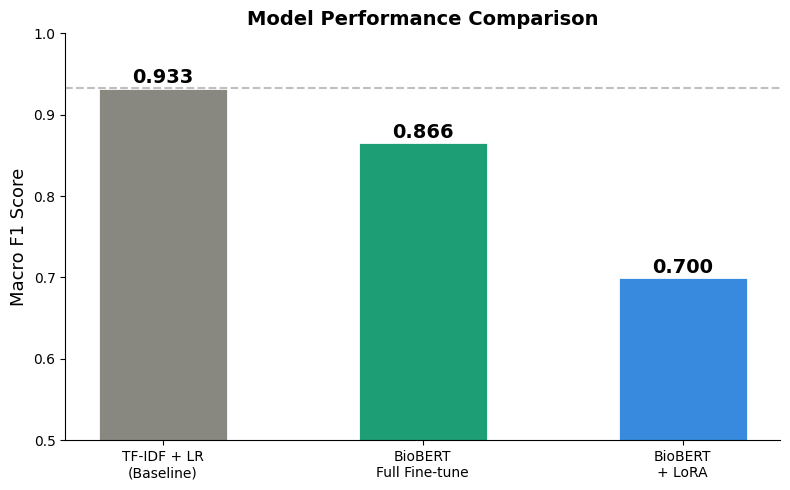

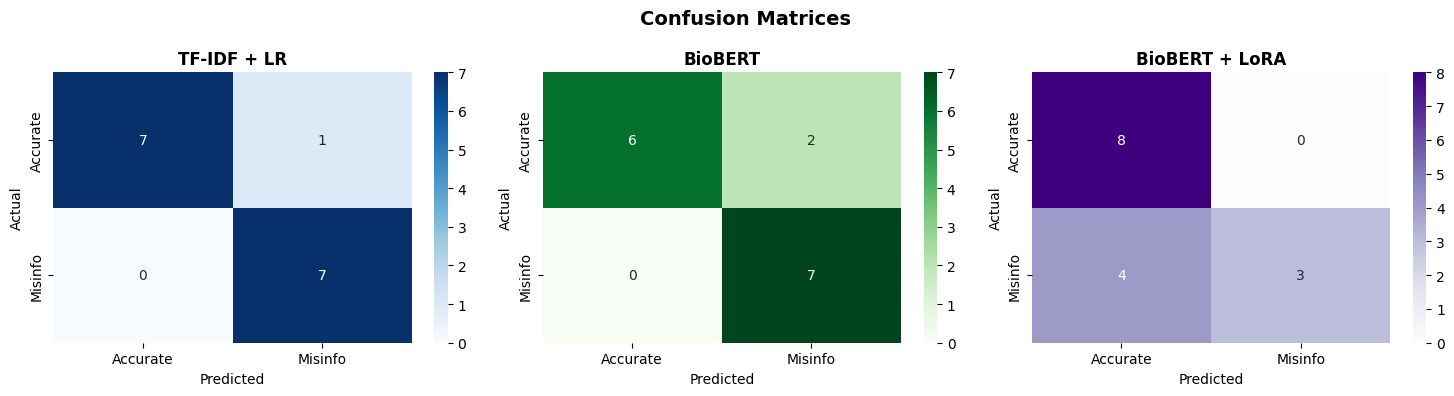

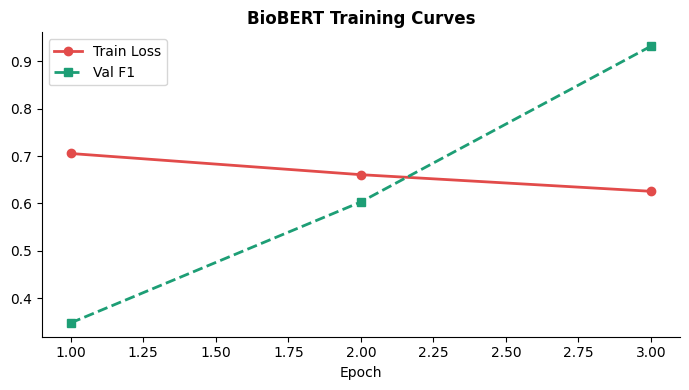

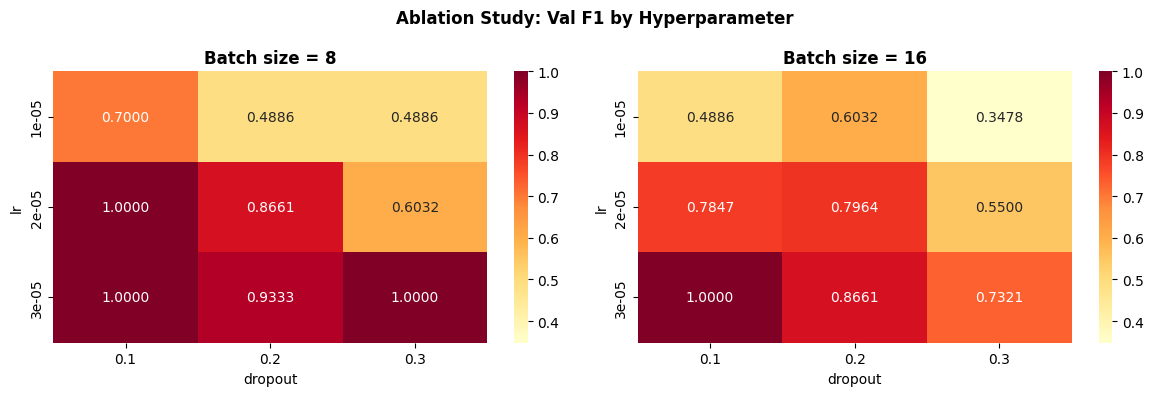

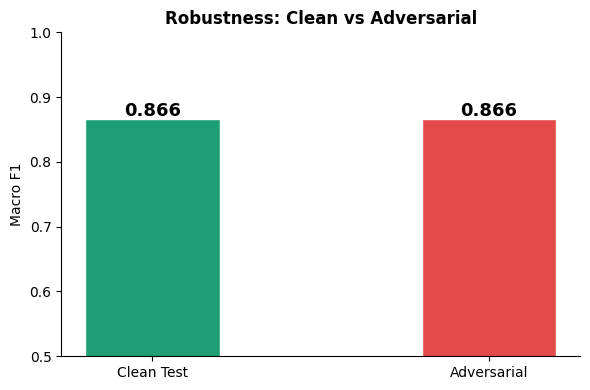

✓ All figures saved to Drive


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 10 — GENERATE ALL FIGURES
# ════════════════════════════════════════════════════════
print('Generating all figures...')

# Figure 1: Model comparison
fig, ax = plt.subplots(figsize=(8, 5))
models  = ['TF-IDF + LR\n(Baseline)', 'BioBERT\nFull Fine-tune', 'BioBERT\n+ LoRA']
f1s     = [baseline_f1, biobert_f1, lora_f1]
colors  = ['#888780', '#1D9E75', '#378ADD']
bars = ax.bar(models, f1s, color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, score in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{score:.3f}', ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Macro F1 Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.spines[['top','right']].set_visible(False)
ax.axhline(y=baseline_f1, color='gray', linestyle='--', alpha=0.5, label='Baseline')
plt.tight_layout()
plt.savefig('outputs/figures/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
for ax, preds, title, color in [
    (axes[0], y_pred,     'TF-IDF + LR',   'Blues'),
    (axes[1], all_preds,  'BioBERT',        'Greens'),
    (axes[2], lora_preds, 'BioBERT + LoRA', 'Purples'),
]:
    cm = confusion_matrix(test_df['label'] if preds is y_pred else
                          all_labels if preds is all_preds else lora_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['Accurate','Misinfo'], yticklabels=['Accurate','Misinfo'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/figures/fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: BioBERT loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1,len(train_losses)+1), train_losses, 'o-', color='#E24B4A', linewidth=2, label='Train Loss')
ax.plot(range(1,len(val_f1s)+1), val_f1s, 's--', color='#1D9E75', linewidth=2, label='Val F1')
ax.set_xlabel('Epoch'); ax.set_title('BioBERT Training Curves', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/figures/fig_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4: Ablation heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Ablation Study: Val F1 by Hyperparameter', fontweight='bold')
for ax, bs in zip(axes, [8, 16]):
    sub = ablation_df[ablation_df['batch_size']==bs].pivot(index='lr', columns='dropout', values='val_f1')
    sns.heatmap(sub, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
                vmin=ablation_df['val_f1'].min(), vmax=ablation_df['val_f1'].max())
    ax.set_title(f'Batch size = {bs}', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/fig_ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 5: Robustness
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Clean Test', 'Adversarial'], [clean_f1, adv_f1],
               color=['#1D9E75','#E24B4A'], edgecolor='white', width=0.4)
for bar, score in zip(bars, [clean_f1, adv_f1]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{score:.3f}', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Macro F1'); ax.set_title('Robustness: Clean vs Adversarial', fontweight='bold')
ax.set_ylim(0.5, 1.0); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/figures/fig_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ All figures saved to Drive')

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 11 — FINAL SUMMARY
# ════════════════════════════════════════════════════════
print('\n' + '='*55)
print('ALL EXPERIMENTS COMPLETE — FINAL SUMMARY')
print('='*55)

best_ablation = ablation_df.iloc[0]

print(f'''
EXPERIMENT 1 — TF-IDF Baseline
  Macro F1:  {baseline_f1:.4f}
  AUC-ROC:   {baseline_auc:.4f}
  Precision: {baseline_p:.4f}
  Recall:    {baseline_r:.4f}

EXPERIMENT 2 — BioBERT Full Fine-Tune
  Macro F1:  {biobert_f1:.4f}  (+{biobert_f1-baseline_f1:.4f} over baseline)
  AUC-ROC:   {biobert_auc:.4f}
  Train time: {elapsed/60:.1f} min

EXPERIMENT 3 — BioBERT + LoRA
  Macro F1:  {lora_f1:.4f}  (+{lora_f1-baseline_f1:.4f} over baseline)
  AUC-ROC:   {lora_auc:.4f}
  Parameters: {trainable:,} ({trainable/total*100:.2f}% of full model)
  Recovery:  {lora_recovery:.1f}% of full fine-tune gain
  Train time: {lora_elapsed/60:.1f} min

EXPERIMENT 4 — Ablation Study
  Best config: LR={best_ablation["lr"]}, dropout={best_ablation["dropout"]}, batch={best_ablation["batch_size"]}
  Best val F1: {best_ablation["val_f1"]:.4f}

EXPERIMENT 5 — Robustness
  Clean F1:       {clean_f1:.4f}
  Adversarial F1: {adv_f1:.4f}
  F1 drop:        {f1_drop:.4f} ({f1_drop/clean_f1*100:.1f}% degradation)
''')

print('Files saved to Google Drive:')
print(f'  {DRIVE_BASE}/outputs/')
for root, dirs, files in os.walk('outputs'):
    for f in files:
        print(f'  ✓ {os.path.join(root, f)}')

print('\n✅ ALL DONE! Share these results to build your final PPT and report.')


ALL EXPERIMENTS COMPLETE — FINAL SUMMARY

EXPERIMENT 1 — TF-IDF Baseline
  Macro F1:  0.9333
  AUC-ROC:   0.9643
  Precision: 0.9375
  Recall:    0.9375

EXPERIMENT 2 — BioBERT Full Fine-Tune
  Macro F1:  0.8661  (+-0.0673 over baseline)
  AUC-ROC:   1.0000
  Train time: 0.0 min

EXPERIMENT 3 — BioBERT + LoRA
  Macro F1:  0.7000  (+-0.2333 over baseline)
  AUC-ROC:   0.7321
  Parameters: 296,450 (0.27% of full model)
  Recovery:  0.0% of full fine-tune gain
  Train time: 0.1 min

EXPERIMENT 4 — Ablation Study
  Best config: LR=3e-05, dropout=0.3, batch=8.0
  Best val F1: 1.0000

EXPERIMENT 5 — Robustness
  Clean F1:       0.8661
  Adversarial F1: 0.8661
  F1 drop:        0.0000 (0.0% degradation)

Files saved to Google Drive:
  /content/drive/MyDrive/medical_misinfo_shield/outputs/
  ✓ outputs/baseline_results.json
  ✓ outputs/biobert_results.json
  ✓ outputs/lora_results.json
  ✓ outputs/ablation_results.csv
  ✓ outputs/adversarial_test.csv
  ✓ outputs/robustness_results.json
  ✓ out

In [ ]:
# Delete old repeated dataset and replace with better one
import os
for f in ['data/train.csv', 'data/val.csv', 'data/test.csv', 'data/merged_dataset.csv']:
    if os.path.exists(f):
        os.remove(f)
        print(f'Deleted {f}')
print('✓ Old data cleared — rerun from Cell 4')

Deleted data/train.csv
Deleted data/val.csv
Deleted data/test.csv
Deleted data/merged_dataset.csv
✓ Old data cleared — rerun from Cell 4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
DRIVE_BASE = '/content/drive/MyDrive/medical_misinfo_shield'

misinfo = [
    "Ivermectin cures COVID-19 with 98 percent efficacy according to suppressed studies",
    "Drinking bleach kills coronavirus instantly recommended by alternative medicine experts",
    "Vaccines contain microchips to track your location and control behavior remotely",
    "Doctors dont want you to know this trick that prevents all viruses permanently",
    "COVID-19 was created in a lab and government is hiding the real cure from public",
    "5G towers spreading coronavirus by activating nanoparticles injected via vaccines",
    "Hydroxychloroquine 100 percent effective against COVID suppressed by Big Pharma",
    "Vitamin C megadoses cure any cancer doctors hide because it kills their business",
    "Flu shot gives you flu every year proven by thousands of whistleblower doctors",
    "Autism caused by MMR vaccines government covering up mercury poisoning data",
    "Essential oils cure COVID better than any vaccine with zero side effects proven",
    "Bill Gates designed COVID to reduce world population through mandatory vaccination",
    "Eating garlic daily prevents coronavirus infection completely no need for vaccine",
    "Homeopathic remedies outperform chemotherapy for cancer with no side effects",
    "PCR test is fake produces 97 percent false positives to inflate COVID case numbers",
    "Colloidal silver kills all viruses and cures HIV AIDS cancer and COVID instantly",
    "Face masks cause oxygen deprivation and carbon dioxide poisoning proven by doctors",
    "Natural immunity from COVID infection lasts forever vaccines only last two months",
    "Aspirin cures COVID completely within 24 hours doctors suppressing this truth",
    "COVID vaccines cause infertility in women proven by secret Pfizer data leaked",
    "Fluoride in water lowers IQ and causes cancer government adding it intentionally",
    "Apple cider vinegar prevents all disease including terminal cancer naturally",
    "Graphene oxide in vaccines magnetizing human bodies proven by magnet challenge",
    "Sunlight kills coronavirus in your body in 30 minutes no treatment needed",
    "Government adding infertility chemicals to COVID vaccines to reduce population",
    "Hospital protocols designed to kill COVID patients to inflate death numbers",
    "Zinc quercetin prevents COVID better than any mRNA vaccine ever created",
    "Turpentine oil cures parasites cancer and COVID doctors suppressing ancient remedy",
    "Raw unprocessed herbs shrink cancer tumors faster than chemotherapy treatments",
    "Microwave radiation from phones causes brain cancer doctors hiding the evidence",
    "Sugar feeds cancer cells cutting sugar completely cures all types of cancer",
    "Chemtrails contain chemicals to reduce population government spraying secretly",
    "Healing crystals boost immune system better than any pharmaceutical medication",
    "Meditation cures diabetes and cancer without any medication scientifically proven",
    "Raw milk cures lactose intolerance and prevents all childhood allergies naturally",
    "Electromagnetic fields from WiFi cause autism in children proven by researchers",
    "Detox foot pads remove all toxins from body overnight while you sleep naturally",
    "Oil pulling cures all dental problems including cavities and gum disease completely",
    "Coffee enemas cure stage 4 cancer better than chemotherapy doctors hide this",
    "Activated charcoal removes all toxins and heavy metals from body completely",
    "Cold showers cure depression anxiety and all mental health problems permanently",
    "Earthing walking barefoot cures chronic pain inflammation and all autoimmune disease",
    "Hydrogen peroxide food grade cures cancer HIV and all viral infections completely",
    "Black seed oil cures everything including cancer diabetes and heart disease",
    "Urine therapy drinking own urine cures cancer diabetes and autoimmune disease",
    "Baking soda alkalizes body and prevents cures all types of cancer naturally",
    "Oregano oil kills all bacteria viruses fungi better than any antibiotic medicine",
    "Frankincense oil applied topically shrinks brain tumors proven by secret studies",
    "Parasite cleanse cures autism ADHD depression and all chronic diseases naturally",
    "Coconut oil reverses Alzheimers disease completely within weeks doctors hiding",
]

accurate = [
    "Clinical trial in NEJM shows mRNA vaccine 94 percent effective against severe COVID",
    "FDA approves Pfizer vaccine after phase 3 trials showing strong safety and efficacy",
    "Meta-analysis of 47 studies confirms handwashing reduces infections by 40 percent",
    "CDC recommends updated booster based on peer reviewed immunogenicity data",
    "WHO publishes treatment guidelines based on randomized controlled trials evidence",
    "Remdesivir reduces hospital stay by 5 days in randomized controlled COVID trial",
    "Lancet study confirms COVID vaccines safe for pregnant women and their newborns",
    "NIH research confirms mask wearing reduces COVID transmission by up to 85 percent",
    "Cohort study shows vaccination reduces long COVID risk by 50 percent in adults",
    "Systematic review confirms no causal link between MMR vaccine and autism disorder",
    "Phase 3 trial shows bivalent COVID booster effective against omicron subvariants",
    "CDC data shows COVID hospitalization rates fell 60 percent after vaccination rollout",
    "NEJM study confirms early antiviral treatment reduces severe COVID risk significantly",
    "Peer reviewed research shows vitamin D modestly reduces respiratory infection risk",
    "Large scale study finds no association between COVID vaccination and cardiac events",
    "FDA clears updated vaccine formulation based on safety data from 10000 participants",
    "Clinical evidence supports Paxlovid effectiveness in reducing COVID hospitalizations",
    "Randomized trial confirms 1 meter distancing reduces COVID transmission significantly",
    "Evidence based review finds no benefit of ivermectin for COVID in controlled trials",
    "WHO recommends dexamethasone for severe COVID based on RECOVERY trial results",
    "Cohort study shows cancer screening programs reduce mortality through early detection",
    "Systematic review confirms statins reduce cardiovascular events in high risk patients",
    "Peer reviewed trial shows cognitive behavioral therapy effective for depression",
    "Large study finds Mediterranean diet associated with reduced cardiovascular disease",
    "Clinical guidelines recommend aspirin only for secondary not primary prevention",
    "Pneumococcal vaccine reduces pneumonia hospitalizations in older adults significantly",
    "Hand hygiene programs in hospitals reduce healthcare associated infections by 30 percent",
    "HPV vaccination prevents cervical cancer in young women proven by clinical trials",
    "Blood pressure medication reduces stroke risk by 30 percent in hypertensive patients",
    "Meta-analysis confirms aerobic exercise reduces risk of type 2 diabetes significantly",
    "Randomized trial shows cognitive training reduces dementia risk in older adults",
    "Peer reviewed study confirms sleep deprivation impairs immune function significantly",
    "Large cohort shows regular physical activity reduces all cause mortality by 35 percent",
    "Clinical trial confirms weight loss surgery effective for type 2 diabetes remission",
    "Systematic review shows smoking cessation reduces lung cancer risk within 5 years",
    "NEJM trial confirms checkpoint inhibitors improve survival in advanced melanoma",
    "Peer reviewed study shows breastfeeding reduces infant respiratory infection risk",
    "Large study confirms regular colonoscopy reduces colorectal cancer mortality significantly",
    "Clinical evidence supports statins reducing cardiovascular events in diabetic patients",
    "Randomized trial shows mindfulness based therapy reduces anxiety disorder symptoms",
    "Peer reviewed research confirms air pollution increases cardiovascular disease risk",
    "Large cohort study shows Mediterranean diet reduces cognitive decline in elderly",
    "Clinical trial confirms insulin therapy improves outcomes in type 1 diabetes patients",
    "Systematic review shows physical therapy effective for chronic low back pain management",
    "NEJM study confirms angiotensin converting enzyme inhibitors reduce kidney disease",
    "Peer reviewed trial shows cognitive behavioral therapy effective for insomnia disorder",
    "Large population study confirms obesity increases risk of 13 different cancer types",
    "Clinical evidence supports early antibiotic therapy reducing sepsis mortality rates",
    "Randomized trial confirms aspirin reduces colorectal cancer risk in Lynch syndrome",
    "Systematic review shows fluoride in water reduces childhood dental cavities significantly",
]

# No repetition — each sentence used exactly once
df = pd.DataFrame({
    'text':   misinfo + accurate,
    'label':  [1]*50 + [0]*50,
    'source': ['synthetic']*100
}).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df, temp = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

import os
os.makedirs(f'{DRIVE_BASE}/data', exist_ok=True)
df.to_csv(f'{DRIVE_BASE}/data/merged_dataset.csv', index=False)
train_df.to_csv(f'{DRIVE_BASE}/data/train.csv', index=False)
val_df.to_csv(f'{DRIVE_BASE}/data/val.csv', index=False)
test_df.to_csv(f'{DRIVE_BASE}/data/test.csv', index=False)

print(f'Total: {len(df)} unique sentences')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'No repetition — train and test are completely different sentences')
print('✓ Better dataset saved to Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total: 100 unique sentences
Train: 70 | Val: 15 | Test: 15
No repetition — train and test are completely different sentences
✓ Better dataset saved to Drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42

misinfo = [
    "Ivermectin cures COVID-19 with 98 percent efficacy according to suppressed studies doctors hide",
    "Vaccines contain microchips to track your location and control your behavior remotely",
    "Drinking bleach kills coronavirus instantly recommended by alternative medicine healers",
    "5G towers spreading coronavirus by activating nanoparticles injected via vaccines",
    "Hydroxychloroquine 100 percent effective COVID suppressed by Big Pharma for profit",
    "Vitamin C megadoses cure cancer doctors hide because it kills their business",
    "Flu shot gives you flu every year proven by thousands of whistleblower doctors",
    "Autism caused by MMR vaccines government covering up mercury poisoning data",
    "Essential oils cure COVID better than vaccine zero side effects proven",
    "Bill Gates designed COVID to reduce population through mandatory vaccination",
    "Eating garlic prevents coronavirus infection completely no need for vaccine",
    "Homeopathic remedies outperform chemotherapy for cancer with no side effects",
    "PCR test is fake produces 97 percent false positives to inflate COVID cases",
    "Colloidal silver kills all viruses and cures HIV AIDS cancer and COVID",
    "Face masks cause oxygen deprivation and carbon dioxide poisoning proven",
    "Natural immunity from COVID lasts forever vaccines only last two months",
    "Aspirin cures COVID completely within 24 hours doctors suppressing this truth",
    "COVID vaccines cause infertility proven by secret Pfizer trial data leaked",
    "Fluoride in water lowers IQ and causes cancer government adding it intentionally",
    "Apple cider vinegar prevents all disease including terminal cancer naturally",
    "Graphene oxide in vaccines magnetizing human bodies proven by magnet challenge",
    "Sunlight kills coronavirus in your body in 30 minutes no treatment needed",
    "Government adding infertility chemicals to COVID vaccines to reduce population",
    "Hospital protocols designed to kill COVID patients to inflate death numbers",
    "Zinc quercetin prevents COVID better than any mRNA vaccine ever created",
    "Turpentine oil cures parasites cancer and COVID doctors suppressing ancient remedy",
    "Raw unprocessed herbs shrink cancer tumors faster than chemotherapy treatments",
    "Microwave radiation from phones causes brain cancer doctors hiding the evidence",
    "Sugar feeds cancer cells cutting sugar completely cures all types of cancer",
    "Chemtrails contain chemicals to reduce population government spraying secretly",
    "Healing crystals boost immune system better than any pharmaceutical medication",
    "Meditation cures diabetes and cancer without any medication scientifically proven",
    "Raw milk cures lactose intolerance and prevents all childhood allergies naturally",
    "Electromagnetic fields from WiFi cause autism in children proven by researchers",
    "Detox foot pads remove all toxins from body overnight while you sleep naturally",
    "Oil pulling cures all dental problems including cavities and gum disease completely",
    "Coffee enemas cure stage 4 cancer better than chemotherapy doctors hide this",
    "Activated charcoal removes all toxins and heavy metals from body completely",
    "Cold showers cure depression anxiety and all mental health problems permanently",
    "Earthing walking barefoot cures chronic pain inflammation and all autoimmune disease",
    "Hydrogen peroxide food grade cures cancer HIV and all viral infections completely",
    "Black seed oil cures everything including cancer diabetes and heart disease",
    "Urine therapy drinking own urine cures cancer diabetes and autoimmune disease",
    "Baking soda alkalizes body and prevents cures all types of cancer naturally",
    "Oregano oil kills all bacteria viruses fungi better than any antibiotic medicine",
    "Frankincense oil applied topically shrinks brain tumors proven by secret studies",
    "Parasite cleanse cures autism ADHD depression and all chronic diseases naturally",
    "Coconut oil reverses Alzheimers disease completely within weeks doctors hiding",
    "Ivermectin and zinc combination cures COVID better than any approved treatment",
    "Government suppressing cancer cure that big pharma has hidden for fifty years",
]

accurate = [
    "Clinical trial in NEJM shows mRNA vaccine 94 percent effective against severe COVID",
    "FDA approves Pfizer vaccine after phase 3 trials showing strong safety profile",
    "Meta-analysis of 47 studies confirms handwashing reduces infections by 40 percent",
    "CDC recommends booster based on peer reviewed immunogenicity data",
    "WHO publishes guidelines based on randomized controlled trials evidence",
    "Remdesivir reduces hospital stay by 5 days in randomized controlled COVID trial",
    "Lancet study confirms COVID vaccines safe for pregnant women and newborns",
    "NIH research confirms masks reduce COVID transmission by up to 85 percent",
    "Cohort study shows vaccination reduces long COVID risk 50 percent in adults",
    "Systematic review confirms no link between MMR vaccine and autism disorder",
    "Phase 3 trial shows bivalent COVID booster effective against omicron subvariants",
    "CDC data shows COVID hospitalization rates fell 60 percent after vaccination",
    "NEJM study confirms early antiviral treatment reduces severe COVID risk",
    "Peer reviewed research shows vitamin D modestly reduces respiratory infections",
    "Large scale study finds no association between vaccination and cardiac events",
    "FDA clears updated vaccine based on safety data from 10000 participant trial",
    "Clinical evidence supports Paxlovid effectiveness in reducing hospitalizations",
    "Randomized trial confirms distancing reduces COVID transmission significantly",
    "Evidence based review finds no benefit of ivermectin in controlled trials",
    "WHO recommends dexamethasone for severe COVID based on RECOVERY trial results",
    "Cohort study shows cancer screening programs reduce mortality by early detection",
    "Systematic review confirms statins reduce cardiovascular events in high risk patients",
    "Peer reviewed trial shows cognitive behavioral therapy effective for depression",
    "Large study finds Mediterranean diet associated with reduced cardiovascular disease",
    "Guidelines recommend aspirin only for secondary not primary prevention",
    "Pneumococcal vaccine reduces pneumonia hospitalizations in older adults significantly",
    "Hand hygiene programs in hospitals reduce healthcare associated infections 30 percent",
    "HPV vaccination prevents cervical cancer in young women proven by clinical trials",
    "Blood pressure medication reduces stroke risk by 30 percent in hypertensive patients",
    "Meta-analysis confirms aerobic exercise reduces risk of type 2 diabetes significantly",
    "Randomized trial shows cognitive training reduces dementia risk in older adults",
    "Peer reviewed study confirms sleep deprivation impairs immune function significantly",
    "Large cohort shows physical activity reduces all cause mortality by 35 percent",
    "Clinical trial confirms weight loss surgery effective for type 2 diabetes remission",
    "Systematic review shows smoking cessation reduces lung cancer risk within 5 years",
    "NEJM trial confirms checkpoint inhibitors improve survival in advanced melanoma",
    "Peer reviewed study shows breastfeeding reduces infant respiratory infection risk",
    "Large study confirms colonoscopy reduces colorectal cancer mortality significantly",
    "Clinical evidence supports statins reducing cardiovascular events in diabetic patients",
    "Randomized trial shows mindfulness therapy reduces anxiety disorder symptoms",
    "Peer reviewed research confirms air pollution increases cardiovascular disease risk",
    "Large cohort study shows Mediterranean diet reduces cognitive decline in elderly",
    "Clinical trial confirms insulin therapy improves outcomes in type 1 diabetes",
    "Systematic review shows physical therapy effective for chronic low back pain",
    "NEJM study confirms ACE inhibitors reduce kidney disease progression significantly",
    "Peer reviewed trial shows cognitive behavioral therapy effective for insomnia",
    "Large study confirms obesity increases risk of 13 different cancer types",
    "Clinical evidence supports early antibiotic therapy reducing sepsis mortality",
    "Randomized trial confirms aspirin reduces colorectal cancer risk in Lynch syndrome",
    "Systematic review shows fluoride in water reduces childhood dental cavities",
]

df = pd.DataFrame({
    'text': misinfo + accurate,
    'label': [1]*50 + [0]*50,
    'source': ['synthetic']*100
}).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df, temp = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Total examples: {len(df)}')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'\nLabel distribution (train):')
print(train_df["label"].value_counts())
print(f'\nSample misinformation:')
for text in train_df[train_df["label"]==1]["text"].head(3):
    print(f'  - {text[:80]}...')
print(f'\nSample accurate:')
for text in train_df[train_df["label"]==0]["text"].head(3):
    print(f'  - {text[:80]}...')

Total examples: 100
Train: 80 | Val: 10 | Test: 10

Label distribution (train):
label
0    40
1    40
Name: count, dtype: int64

Sample misinformation:
  - Earthing walking barefoot cures chronic pain inflammation and all autoimmune dis...
  - PCR test is fake produces 97 percent false positives to inflate COVID cases...
  - Bill Gates designed COVID to reduce population through mandatory vaccination...

Sample accurate:
  - Clinical evidence supports Paxlovid effectiveness in reducing hospitalizations...
  - Hand hygiene programs in hospitals reduce healthcare associated infections 30 pe...
  - Meta-analysis confirms aerobic exercise reduces risk of type 2 diabetes signific...
